# Helmholtz 2D — PINN con campo complejo y LHS
### Proyecto: Simulación Acelerada de Speckle Óptico
**Roberto Hernández Estrada** | Maestría en Ciencias de la Computación — UJAT
**Director:** Dr. José Adán Hernández Nolasco

---

| Notebook | Estado |
|---|---|
| `01_teoria_pinns_completo.ipynb` — Helmholtz 1D, validación SIREN | ✅ Completado — Error L2 = 0.002% |
| **`02_helmholtz_2D.ipynb` — Helmholtz 2D, campo complejo, LHS** | 🔄 En desarrollo |
| `03_speckle.ipynb` — Simulación de speckle I = |E|² | 🔜 Pendiente |
| `04_benchmark.ipynb` — PINN vs FEniCSx (Speed-up Factor) | 🔜 Pendiente |

---

## ¿Qué resuelve este notebook?

En el notebook 01 validaste que la PINN con arquitectura **SIREN (ω₀=1.0)** puede resolver Helmholtz **1D** con error L2 = 0.002%.
Este notebook escala al problema **real de la tesis**: Helmholtz en 2 dimensiones con campo complejo.

$$\nabla^2 E + k^2 E = 0 \quad \Longrightarrow \quad
\frac{\partial^2 E}{\partial x^2} + \frac{\partial^2 E}{\partial y^2} + (2\pi)^2 E = 0$$

La diferencia clave: el campo óptico $E(x,y)$ es **complejo**, así que la PINN predice **dos salidas**:

$$E(x,y) = E_{\text{real}}(x,y) + i \cdot E_{\text{imag}}(x,y)$$

## Diferencias clave respecto al notebook 01

| Aspecto | Notebook 01 (1D) | Notebook 02 (2D) |
|---|---|---|
| Entrada de la red | $x$ (1 valor) | $(x, y)$ (2 valores) |
| Salida de la red | $E$ real (1 valor) | $(E_{\text{real}}, E_{\text{imag}})$ (2 valores) |
| Ecuación | $E'' + k^2 E = 0$ | $\nabla^2 E + k^2 E = 0$ |
| Muestreo interior | Linspace uniforme | Latin Hypercube Sampling (LHS) |
| Condiciones de frontera | 5 puntos conocidos | 4 bordes del dominio $[0,1]^2$ |
| Activación | SIREN sin(ω₀·x), ω₀=1.0 | SIREN sin(ω₀·x), ω₀=1.0 |
| Early stopping | Umbral fijo L < 1e-4 | Paciencia (N épocas sin mejora) |
| Visualización | Gráfica 1D | Mapa de calor 2D (heatmap) |

## 0. Imports y configuración del entorno

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from scipy.stats import qmc  # Latin Hypercube Sampling

# ── Semilla global — SIEMPRE al inicio para reproducibilidad ──────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Dispositivo ───────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo     : {device}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM total      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Semilla fijada  : {SEED}')
print()
print('Entorno listo y reproducible.')

Dispositivo     : cpu
Semilla fijada  : 42

Entorno listo y reproducible.


---
## 1. Arquitectura de la red — PINN 2D SIREN

La red recibe dos coordenadas $(x, y)$ y predice dos salidas $(E_{\text{real}}, E_{\text{imag}})$.
La arquitectura es **SIREN** — idéntica a NB01 en estructura, extendida a entrada 2D y salida 2D.

### ¿Por qué dos salidas?

El campo eléctrico óptico es una cantidad **compleja**:

$$E(x,y) = E_{\text{real}}(x,y) + i \cdot E_{\text{imag}}(x,y)$$

Las redes neuronales reales solo manejan números reales, así que la estrategia estándar en PINNs ópticas
es entrenar **una sola red con dos salidas**, una por cada parte del campo.

Ambas partes satisfacen la ecuación de Helmholtz de forma independiente:

$$\nabla^2 E_{\text{real}} + k^2 E_{\text{real}} = 0$$
$$\nabla^2 E_{\text{imag}} + k^2 E_{\text{imag}} = 0$$

La intensidad del speckle (lo que mide el detector) se obtiene después:

$$I(x,y) = |E|^2 = E_{\text{real}}^2 + E_{\text{imag}}^2$$

### ¿Por qué SIREN y no tanh?

Misma justificación que en NB01 — la inicialización de Sitzmann et al. (2020) garantiza
estabilidad de las derivadas de segundo orden necesarias para el laplaciano.
Con `λ=1.0` y SIREN, datos y física están equilibrados desde el inicio sin necesidad
de reducir el peso de la física.

In [2]:
class Sine(nn.Module):
    """Activación sinusoidal SIREN con escalamiento de frecuencia omega_0."""
    def __init__(self, omega_0=1.0):
        super().__init__()
        self.omega_0 = omega_0

    def forward(self, x):
        return torch.sin(self.omega_0 * x)


class PINN_2D_SIREN(nn.Module):
    """
    SIREN para resolver Helmholtz 2D: ∇²E + k²E = 0

    Entrada : (x, y) — coordenadas espaciales 2D
    Salida  : (E_real, E_imag) — partes real e imaginaria del campo complejo
    Activación: sin(ω₀·x) — misma familia que las soluciones de Helmholtz
    """
    def __init__(self, hidden_dim=64, num_layers=5, omega_0=1.0):
        super().__init__()
        self.omega_0    = omega_0
        self.hidden_dim = hidden_dim

        # Entrada: 2 neuronas (x, y)
        layers = [nn.Linear(2, hidden_dim), Sine(omega_0=omega_0)]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), Sine(omega_0=omega_0)]
        layers.append(nn.Linear(hidden_dim, 2))   # 2 salidas: E_real, E_imag

        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        """Inicialización de Sitzmann et al. (2020) — necesaria para SIREN."""
        with torch.no_grad():
            for i, layer in enumerate(self.net):
                if isinstance(layer, nn.Linear):
                    n_in = layer.weight.shape[1]
                    if i == 0:
                        layer.weight.uniform_(-1 / n_in, 1 / n_in)
                    else:
                        layer.weight.uniform_(
                            -np.sqrt(6 / n_in) / self.omega_0,
                             np.sqrt(6 / n_in) / self.omega_0
                        )
                    nn.init.zeros_(layer.bias)

    def forward(self, xy):
        """
        xy : tensor (N, 2) con columnas [x, y]
        Retorna tensor (N, 2) con columnas [E_real, E_imag]
        """
        return self.net(xy)


# ── Vista previa ───────────────────────────────────────────────────────────────
torch.manual_seed(SEED)
_preview = PINN_2D_SIREN(hidden_dim=64, num_layers=5, omega_0=1.0)
print('Arquitectura PINN_2D_SIREN:')
print(_preview)
print(f'\nTotal de parámetros : {sum(p.numel() for p in _preview.parameters()):,}')
print(f'Activación          : sin(ω₀·x) con ω₀=1.0')
print(f'Inicialización      : Sitzmann et al. (2020)')
del _preview

Arquitectura PINN_2D_SIREN:
PINN_2D_SIREN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Sine()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Sine()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Sine()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Sine()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): Sine()
    (10): Linear(in_features=64, out_features=2, bias=True)
  )
)

Total de parámetros : 16,962
Activación          : sin(ω₀·x) con ω₀=1.0
Inicialización      : Sitzmann et al. (2020)


---
## 2. Muestreo LHS — Latin Hypercube Sampling

En 1D usamos `linspace` para distribuir puntos uniformemente.
En 2D necesitamos una estrategia más eficiente: **Latin Hypercube Sampling**.

### ¿Por qué LHS en lugar de una malla uniforme?

Con una malla uniforme de $N \times N$ puntos en 2D, el número de puntos crece cuadráticamente.
Para $N=45$ ya son 2,025 puntos — y muchos quedan agrupados en regiones redundantes.

LHS garantiza que los puntos estén **bien distribuidos en todo el dominio** con menos puntos:

| Muestreo | 2000 puntos en [0,1]² | Cobertura | Costo |
|---|---|---|---|
| Malla uniforme | 44×44 = 1,936 pts | Regular pero redundante | Fijo |
| Aleatorio puro | 2000 pts | Irregular, huecos | Variable |
| **LHS** | **2000 pts** | **Uniforme garantizada** | **Controlado** |

LHS divide cada dimensión en $N$ estratos iguales y coloca exactamente un punto en cada estrato,
asegurando cobertura completa sin agrupamientos.

---
## 3. Configuración del experimento

Todos los hiperparámetros en un solo lugar.
Arquitectura y pesos heredados de NB01 — validados con SIREN.

### Solución analítica en 2D

Para validar la PINN necesitamos una solución exacta conocida.
Usamos una onda plana que satisface Helmholtz 2D exactamente:

$$E_{\text{real}}(x,y) = \cos(k_x x + k_y y), \quad E_{\text{imag}}(x,y) = \sin(k_x x + k_y y)$$

con $k_x^2 + k_y^2 = k^2 = (2\pi)^2$.

La elección más simple y simétrica:

$$k_x = k_y = \frac{k}{\sqrt{2}} = \frac{2\pi}{\sqrt{2}} = \pi\sqrt{2}$$

**Verificación:** $k_x^2 + k_y^2 = 2\pi^2 + 2\pi^2 = 4\pi^2 = k^2$ ✅

In [3]:
# ── Hiperparámetros ────────────────────────────────────────────────────────────
CONFIG = {
    # ── Láser simulado (documentación) ────────────────────────────────────────
    'lambda_laser' : 638e-9,      # diodo rojo λ = 638 nm (computacional)
    'L'            : 1,           # dominio = 1×1 longitudes de onda

    # ── Física adimensional ────────────────────────────────────────────────────
    'k'            : 2 * np.pi,   # k̃ adimensional — siempre 2π

    # ── Puntos de colocación (LHS) ─────────────────────────────────────────────
    'N_colloc'     : 2000,        # puntos interiores — Latin Hypercube Sampling
    'N_boundary'   : 200,         # puntos por borde (4 bordes → 800 total)

    # ── Arquitectura SIREN ─────────────────────────────────────────────────────
    'hidden_dim'   : 64,          # neuronas por capa oculta
    'num_layers'   : 5,           # capas ocultas
    'omega_0'      : 1.0,         # frecuencia SIREN — calibrado para k=2π en NB01

    # ── Entrenamiento ──────────────────────────────────────────────────────────
    'n_epochs'     : 15000,       # épocas máximas Adam
    'lr'           : 1e-3,        # learning rate inicial Adam
    'lambda_phys'  : 0.1,         # ← AJUSTADO: era 1.0 — en 2D el residuo es doble
                                   #   (L_real + L_imag), 0.1 balancea datos y física
    'patience'     : 500,         # early stopping por paciencia

    # ── LR Scheduler ──────────────────────────────────────────────────────────
    'scheduler_step': 3000,       # ← NUEVO: reducir lr cada N épocas
    'scheduler_gamma': 0.5,       # ← NUEVO: factor de reducción (lr × 0.5)
                                   #   lr: 1e-3 → 5e-4 → 2.5e-4 → 1.25e-4

    # ── L-BFGS ────────────────────────────────────────────────────────────────
    'lbfgs_max_iter'  : 1000,     # ← NUEVO: era 500 — L-BFGS es rápido (~18s/526 iter)
    'lbfgs_history'   : 100,      # ← NUEVO: era 50 — más historia, mejor aproximación

    # ── Reproducibilidad ───────────────────────────────────────────────────────
    'seed'         : SEED,

    # ── Meta de la tesis ───────────────────────────────────────────────────────
    'l2_threshold' : 0.05,
}

print('Configuración del experimento:')
print('-' * 46)
for key, val in CONFIG.items():
    print(f'  {key:<20} : {val}')
print('-' * 46)

k   = CONFIG['k']
k_x = k / np.sqrt(2)
k_y = k / np.sqrt(2)
print(f'  k_x = k/√2       : {k_x:.4f}')
print(f'  k_y = k/√2       : {k_y:.4f}')
print(f'  Verificación k²  : {k_x**2 + k_y**2:.4f} = k² = {k**2:.4f} ✅')
print()

lam = CONFIG['lambda_laser']
L   = CONFIG['L']
print('Láser simulado:')
print(f'  lambda_laser        : {lam * 1e9:.0f} nm')
print(f'  k adimensional      : 2π = {k:.4f}')
print(f'  k real equivalente  : {2 * np.pi / lam:.3e} m⁻¹')
print(f'  Dominio simulado    : {L}×{L} longitudes de onda')
print(f'  Equivale físicamente: {L * lam * 1e6:.4f} × {L * lam * 1e6:.4f} μm²')


Configuración del experimento:
----------------------------------------------
  lambda_laser         : 6.38e-07
  L                    : 1
  k                    : 6.283185307179586
  N_colloc             : 2000
  N_boundary           : 200
  hidden_dim           : 64
  num_layers           : 5
  omega_0              : 1.0
  n_epochs             : 15000
  lr                   : 0.001
  lambda_phys          : 0.1
  patience             : 500
  scheduler_step       : 3000
  scheduler_gamma      : 0.5
  lbfgs_max_iter       : 1000
  lbfgs_history        : 100
  seed                 : 42
  l2_threshold         : 0.05
----------------------------------------------
  k_x = k/√2       : 4.4429
  k_y = k/√2       : 4.4429
  Verificación k²  : 39.4784 = k² = 39.4784 ✅

Láser simulado:
  lambda_laser        : 638 nm
  k adimensional      : 2π = 6.2832
  k real equivalente  : 9.848e+06 m⁻¹
  Dominio simulado    : 1×1 longitudes de onda
  Equivale físicamente: 0.6380 × 0.6380 μm²


---
## 4. Preparar datos de entrenamiento

### Puntos de colocación — LHS en el interior
### Condiciones de frontera — 4 bordes del dominio $[0,1]^2$

### La función de pérdida PINN 2D

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{datos}} + \lambda \cdot (\mathcal{L}_{\text{física,real}} + \mathcal{L}_{\text{física,imag}})$$

| Término | Qué mide | Dónde |
|---|---|---|
| $\mathcal{L}_{\text{datos}}$ | Error en los 4 bordes | 800 puntos de frontera |
| $\mathcal{L}_{\text{física,real}}$ | Residuo Helmholtz de E_real | 2000 puntos LHS |
| $\mathcal{L}_{\text{física,imag}}$ | Residuo Helmholtz de E_imag | 2000 puntos LHS |

> **`λ=1.0`** — mismo valor validado con SIREN en NB01. La inicialización de Sitzmann
> garantiza que datos y física estén equilibrados desde el inicio.

In [4]:
k   = CONFIG['k']
k_x = k / np.sqrt(2)
k_y = k / np.sqrt(2)

# ── Puntos interiores con LHS ──────────────────────────────────────────────────
sampler   = qmc.LatinHypercube(d=2, seed=CONFIG['seed'])
lhs_pts   = sampler.random(n=CONFIG['N_colloc'])
xy_colloc = torch.tensor(lhs_pts, dtype=torch.float32).to(device)

print(f'Puntos de colocación (LHS): {xy_colloc.shape}  → {CONFIG["N_colloc"]} puntos en [0,1]²')

# ── Condiciones de frontera — 4 bordes ────────────────────────────────────────
N_b  = CONFIG['N_boundary']
t    = np.linspace(0, 1, N_b)

x_bot = np.stack([t,             np.zeros(N_b)], axis=1)
x_top = np.stack([t,             np.ones(N_b)],  axis=1)
x_lft = np.stack([np.zeros(N_b), t],             axis=1)
x_rgt = np.stack([np.ones(N_b),  t],             axis=1)

xy_bc_np = np.vstack([x_bot, x_top, x_lft, x_rgt])

phase_bc     = k_x * xy_bc_np[:, 0] + k_y * xy_bc_np[:, 1]
E_real_bc_np = np.cos(phase_bc)
E_imag_bc_np = np.sin(phase_bc)
E_bc_np      = np.stack([E_real_bc_np, E_imag_bc_np], axis=1)

xy_bc = torch.tensor(xy_bc_np, dtype=torch.float32).to(device)
E_bc  = torch.tensor(E_bc_np,  dtype=torch.float32).to(device)

print(f'Puntos de frontera         : {xy_bc.shape}  → {4*N_b} puntos ({N_b} por borde)')
print(f'  Borde inferior (y=0)     : {N_b} puntos')
print(f'  Borde superior (y=1)     : {N_b} puntos')
print(f'  Borde izquierdo (x=0)    : {N_b} puntos')
print(f'  Borde derecho (x=1)      : {N_b} puntos')
print()
print('Muestra de condiciones de frontera:')
print(f'  E(0,0)   real={E_real_bc_np[0]:.4f}   imag={E_imag_bc_np[0]:.4f}')
print(f'  E(0.5,0) real={np.cos(k_x*0.5):.4f}   imag={np.sin(k_x*0.5):.4f}')
print(f'  E(1,1)   real={np.cos(k_x+k_y):.4f}   imag={np.sin(k_x+k_y):.4f}')

Puntos de colocación (LHS): torch.Size([2000, 2])  → 2000 puntos en [0,1]²
Puntos de frontera         : torch.Size([800, 2])  → 800 puntos (200 por borde)
  Borde inferior (y=0)     : 200 puntos
  Borde superior (y=1)     : 200 puntos
  Borde izquierdo (x=0)    : 200 puntos
  Borde derecho (x=1)      : 200 puntos

Muestra de condiciones de frontera:
  E(0,0)   real=1.0000   imag=0.0000
  E(0.5,0) real=-0.6057   imag=0.7957
  E(1,1)   real=-0.8582   imag=0.5133


---
## 5. Funciones auxiliares — Derivadas y Residuo de Helmholtz 2D

Estas funciones calculan las derivadas de la red usando **autograd** y evalúan
qué tanto viola la ecuación de Helmholtz en cada punto del dominio $[0,1]^2$.

### ¿Qué cambia respecto a 1D?

En 1D el residuo era una sola derivada de segundo orden:

$$R(x) = \frac{d^2E}{dx^2} + k^2 E$$

En 2D el residuo involucra el **laplaciano** — derivadas parciales en ambas dimensiones simultáneamente:

$$R(x,y) = \frac{\partial^2 E}{\partial x^2} + \frac{\partial^2 E}{\partial y^2} + k^2 E = \nabla^2 E + k^2 E$$

Y como el campo es complejo, se evalúa para **ambas partes por separado**:

$$R_{\text{real}}(x,y) = \nabla^2 E_{\text{real}} + k^2 E_{\text{real}} = 0$$
$$R_{\text{imag}}(x,y) = \nabla^2 E_{\text{imag}} + k^2 E_{\text{imag}} = 0$$

### ¿Cómo calcula autograd el laplaciano en 2D?

El mismo principio que en 1D — PyTorch construye el grafo computacional y lo recorre
al revés — pero ahora en **dos pasos por dimensión**:

```
forward:  (x,y) → operaciones → E_real, E_imag     (PyTorch registra todo)

backward paso 1:  E → ∂E/∂x,  ∂E/∂y               (gradiente espacial — vector 2D)
backward paso 2:  ∂E/∂x → ∂²E/∂x²                 (segunda derivada en x)
                  ∂E/∂y → ∂²E/∂y²                 (segunda derivada en y)

laplaciano:  ∂²E/∂x² + ∂²E/∂y²
```

> **Clave:** el tensor de entrada es `(N, 2)` con columnas `[x, y]`.
> PyTorch calcula los gradientes respecto a **cada columna por separado**,
> por eso `grad_f[:, 0]` es la derivada en x y `grad_f[:, 1]` en y.
> Ambas con `requires_grad=True` desde el inicio del forward.

| Situación | R_real | R_imag |
|---|---|---|
| Red perfecta | 0 en todo [0,1]² | 0 en todo [0,1]² |
| Red sin entrenar | Valores grandes | Valores grandes |
| Durante entrenamiento | → 0 gradualmente | → 0 gradualmente |

In [5]:
def helmholtz_residual_2d(model, xy_colloc, k):
    """
    Residuo de Helmholtz 2D para ambas partes del campo:
        R_real = ∂²E_real/∂x² + ∂²E_real/∂y² + k²·E_real
        R_imag = ∂²E_imag/∂x² + ∂²E_imag/∂y² + k²·E_imag
    Si la red es perfecta → R_real = R_imag = 0 en todo el dominio.
    """
    xy = xy_colloc.clone().requires_grad_(True)

    E_out  = model(xy)
    E_real = E_out[:, 0:1]
    E_imag = E_out[:, 1:2]
    ones   = torch.ones_like(E_real)

    def laplacian(field):
        grad_f = torch.autograd.grad(field, xy, grad_outputs=ones,
                                     create_graph=True)[0]
        f_xx = torch.autograd.grad(grad_f[:, 0:1], xy, grad_outputs=ones,
                                   create_graph=True)[0][:, 0:1]
        f_yy = torch.autograd.grad(grad_f[:, 1:2], xy, grad_outputs=ones,
                                   create_graph=True)[0][:, 1:2]
        return f_xx + f_yy

    res_real = laplacian(E_real) + k**2 * E_real
    res_imag = laplacian(E_imag) + k**2 * E_imag

    return res_real, res_imag, E_real, E_imag


def pinn_loss_2d(model, xy_colloc, xy_bc, E_bc, k, lambda_phys):
    """
    L_total = L_datos + λ · (L_física_real + L_física_imag)
    """
    E_pred_bc = model(xy_bc)
    loss_data = torch.mean((E_pred_bc - E_bc) ** 2)

    res_real, res_imag, _, _ = helmholtz_residual_2d(model, xy_colloc, k)
    loss_physics = torch.mean(res_real ** 2) + torch.mean(res_imag ** 2)

    return loss_data + lambda_phys * loss_physics, loss_data, loss_physics


print('Funciones auxiliares 2D definidas.')
print('   helmholtz_residual_2d() — ∇²E_real + k²E_real  y  ∇²E_imag + k²E_imag')
print('   pinn_loss_2d()          — L_total = L_datos + λ·(L_real + L_imag)')

Funciones auxiliares 2D definidas.
   helmholtz_residual_2d() — ∇²E_real + k²E_real  y  ∇²E_imag + k²E_imag
   pinn_loss_2d()          — L_total = L_datos + λ·(L_real + L_imag)


### Estrategia de entrenamiento

La misma estrategia de NB01, con dos mejoras aplicadas a partir de los resultados
del primer intento (Error L2 = 94.6% con λ=1.0):

| Fase | Optimizador | Rol |
|---|---|---|
| 1 | Adam + LR Scheduler | Exploración global con learning rate decreciente |
| — | Early stopping por **paciencia** | Para si no hay mejora en N épocas consecutivas |
| 2 | L-BFGS (1000 iter) | Ajuste fino de alta precisión cerca del mínimo |

**Cambio 1 — `lambda_phys: 1.0 → 0.1`**
En 2D la pérdida física es `L_real + L_imag` — dos términos en lugar de uno.
Con λ=1.0 el peso efectivo de la física era el doble que en 1D, impidiendo que
la red aprendiera las condiciones de frontera correctamente.

**Cambio 2 — LR Scheduler (StepLR)**
Reduce el learning rate a la mitad cada 3,000 épocas:
`1e-3 → 5e-4 → 2.5e-4 → 1.25e-4`. Las épocas finales de Adam tienen pasos
más pequeños y precisos, dando un mejor punto de partida a L-BFGS.

**Cambio 3 — L-BFGS max_iter: 500 → 1000**
En el primer intento L-BFGS usó 526 iteraciones (llegó al límite) sin converger
completamente. Doblar el límite cuesta ~35 s adicionales y permite convergencia
completa desde el punto que deja Adam.

### Estrategia de entrenamiento

La misma estrategia de NB01, con un cambio clave en el early stopping:

| Fase | Optimizador | Rol |
|---|---|---|
| 1 | Adam | Exploración global del espacio de parámetros |
| — | Early stopping por **paciencia** | Para si no hay mejora en N épocas consecutivas |
| 2 | L-BFGS | Ajuste fino de alta precisión cerca del mínimo |

> **¿Por qué paciencia en lugar de umbral fijo?**
> En NB01, el umbral `L_total < 1e-4` nunca se activó porque SIREN con `λ=1.0`
> oscila alrededor de ese valor sin cruzarlo. La paciencia detecta el estancamiento
> real de Adam y transfiere a L-BFGS desde el mejor punto encontrado.

In [6]:
# ── Semilla antes de instanciar ───────────────────────────────────────────────
torch.manual_seed(CONFIG['seed'])
torch.cuda.manual_seed(CONFIG['seed'])

# ── Modelo SIREN 2D ───────────────────────────────────────────────────────────
model_2d = PINN_2D_SIREN(
    hidden_dim = CONFIG['hidden_dim'],
    num_layers = CONFIG['num_layers'],
    omega_0    = CONFIG['omega_0']
).to(device)

print(f'Modelo: PINN_2D_SIREN | {CONFIG["num_layers"]} capas × {CONFIG["hidden_dim"]} | '
      f'ω₀={CONFIG["omega_0"]} | {sum(p.numel() for p in model_2d.parameters()):,} parámetros')

optimizer = torch.optim.Adam(model_2d.parameters(), lr=CONFIG['lr'])

# ── LR Scheduler — StepLR ─────────────────────────────────────────────────────
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size = CONFIG['scheduler_step'],   # cada 3,000 épocas
    gamma     = CONFIG['scheduler_gamma']   # lr × 0.5
)
print(f'LR Scheduler: StepLR — reduce lr×{CONFIG["scheduler_gamma"]} '
      f'cada {CONFIG["scheduler_step"]} épocas')
print(f'  Progresión lr: {CONFIG["lr"]:.0e} → '
      f'{CONFIG["lr"]*CONFIG["scheduler_gamma"]:.0e} → '
      f'{CONFIG["lr"]*CONFIG["scheduler_gamma"]**2:.0e} → '
      f'{CONFIG["lr"]*CONFIG["scheduler_gamma"]**3:.0e}')

# ── Early stopping por paciencia ──────────────────────────────────────────────
PATIENCE  = CONFIG['patience']
MIN_DELTA = 1e-7
best_loss  = float('inf')
best_state = None
sin_mejora = 0

history = {'total': [], 'data': [], 'physics': [], 'lr': []}

print(f'\nEntrenando PINN 2D...')
print(f'  k={k:.4f} | LHS {CONFIG["N_colloc"]} pts | {4*CONFIG["N_boundary"]} pts frontera')
print(f'  Épocas máx: {CONFIG["n_epochs"]} | lr inicial={CONFIG["lr"]} | λ={CONFIG["lambda_phys"]}')
print(f'  Early stopping: paciencia = {PATIENCE} épocas sin mejora')
print()

epoch_final = CONFIG['n_epochs']
t0_adam = time.time()

for epoch in range(CONFIG['n_epochs']):
    optimizer.zero_grad()

    loss, loss_data, loss_physics = pinn_loss_2d(
        model_2d, xy_colloc, xy_bc, E_bc,
        k           = CONFIG['k'],
        lambda_phys = CONFIG['lambda_phys']
    )

    loss.backward()
    optimizer.step()
    scheduler.step()   # ← actualizar lr al final de cada época

    current_loss = loss.item()
    current_lr   = optimizer.param_groups[0]['lr']
    history['total'].append(current_loss)
    history['data'].append(loss_data.item())
    history['physics'].append(loss_physics.item())
    history['lr'].append(current_lr)

    # ── Paciencia ──────────────────────────────────────────────────────────────
    if current_loss < best_loss - MIN_DELTA:
        best_loss  = current_loss
        best_state = {k_: v.clone() for k_, v in model_2d.state_dict().items()}
        sin_mejora = 0
    else:
        sin_mejora += 1

    if (epoch + 1) % 500 == 0:
        print(f'  Época {epoch+1:5d} | '
              f'L_total: {current_loss:.3e} | '
              f'Mejor: {best_loss:.3e} | '
              f'lr: {current_lr:.2e} | '
              f'Sin mejora: {sin_mejora}')

    if sin_mejora >= PATIENCE:
        epoch_final = epoch + 1
        print(f'\n  Early stopping por paciencia en época {epoch_final}')
        print(f'  Restaurando mejor modelo (loss={best_loss:.3e})')
        model_2d.load_state_dict(best_state)
        break

t1_adam = time.time()
tiempo_adam = t1_adam - t0_adam
print(f'\nAdam completado en {epoch_final} épocas — {tiempo_adam:.1f} segundos')
print(f'  lr final usado: {history["lr"][-1]:.2e}')

# ── Ajuste fino con L-BFGS ────────────────────────────────────────────────────
print('\nAjuste fino con L-BFGS...')

optimizer_lbfgs = torch.optim.LBFGS(
    model_2d.parameters(),
    lr             = 1.0,
    max_iter       = CONFIG['lbfgs_max_iter'],   # 1000 — era 500
    history_size   = CONFIG['lbfgs_history'],    # 100  — era 50
    line_search_fn = 'strong_wolfe'
)
print(f'  max_iter={CONFIG["lbfgs_max_iter"]} | history_size={CONFIG["lbfgs_history"]}')

history_lbfgs = {'total': [], 'data': [], 'physics': []}
iter_count    = [0]
t0_lbfgs      = time.time()

def closure():
    optimizer_lbfgs.zero_grad()
    loss, loss_data, loss_physics = pinn_loss_2d(
        model_2d, xy_colloc, xy_bc, E_bc,
        k           = CONFIG['k'],
        lambda_phys = CONFIG['lambda_phys']
    )
    loss.backward()
    history_lbfgs['total'].append(loss.item())
    history_lbfgs['data'].append(loss_data.item())
    history_lbfgs['physics'].append(loss_physics.item())
    iter_count[0] += 1
    if iter_count[0] % 100 == 0:
        print(f'  Iter {iter_count[0]:4d} | '
              f'L_total: {loss.item():.3e} | '
              f'L_datos: {loss_data.item():.3e} | '
              f'L_física: {loss_physics.item():.3e}')
    return loss

optimizer_lbfgs.step(closure)
t1_lbfgs = time.time()
tiempo_lbfgs = t1_lbfgs - t0_lbfgs

print(f'\nL-BFGS completado.')
print(f'  Épocas Adam       : {epoch_final} / {CONFIG["n_epochs"]}')
print(f'  Tiempo Adam       : {tiempo_adam:.1f} s')
print(f'  Iteraciones L-BFGS: {iter_count[0]} / {CONFIG["lbfgs_max_iter"]}')
print(f'  Tiempo L-BFGS     : {tiempo_lbfgs:.1f} s')
print(f'  Tiempo TOTAL      : {tiempo_adam + tiempo_lbfgs:.1f} s')


Modelo: PINN_2D_SIREN | 5 capas × 64 | ω₀=1.0 | 16,962 parámetros
LR Scheduler: StepLR — reduce lr×0.5 cada 3000 épocas
  Progresión lr: 1e-03 → 5e-04 → 3e-04 → 1e-04

Entrenando PINN 2D...
  k=6.2832 | LHS 2000 pts | 800 pts frontera
  Épocas máx: 15000 | lr inicial=0.001 | λ=0.1
  Early stopping: paciencia = 500 épocas sin mejora

  Época   500 | L_total: 4.937e-01 | Mejor: 4.937e-01 | lr: 1.00e-03 | Sin mejora: 0
  Época  1000 | L_total: 4.881e-01 | Mejor: 4.881e-01 | lr: 1.00e-03 | Sin mejora: 0
  Época  1500 | L_total: 4.810e-01 | Mejor: 4.810e-01 | lr: 1.00e-03 | Sin mejora: 0
  Época  2000 | L_total: 4.681e-01 | Mejor: 4.681e-01 | lr: 1.00e-03 | Sin mejora: 0
  Época  2500 | L_total: 4.899e-01 | Mejor: 4.482e-01 | lr: 1.00e-03 | Sin mejora: 36
  Época  3000 | L_total: 4.272e-01 | Mejor: 4.269e-01 | lr: 5.00e-04 | Sin mejora: 2
  Época  3500 | L_total: 4.122e-01 | Mejor: 4.122e-01 | lr: 5.00e-04 | Sin mejora: 0
  Época  4000 | L_total: 3.877e-01 | Mejor: 3.877e-01 | lr: 5.00e-04 

---
## 7. Evaluación y visualización de resultados

Evaluamos la PINN en una malla uniforme de $100 \times 100$ puntos (10,000 puntos de prueba)
y comparamos contra la solución analítica exacta.

In [7]:
# ── Malla de evaluación 100×100 ───────────────────────────────────────────────
N_eval = 100
x_lin  = np.linspace(0, 1, N_eval)
y_lin  = np.linspace(0, 1, N_eval)
XX, YY = np.meshgrid(x_lin, y_lin)

xy_test_np = np.stack([XX.ravel(), YY.ravel()], axis=1)
xy_test    = torch.tensor(xy_test_np, dtype=torch.float32).to(device)

model_2d.eval()
with torch.no_grad():
    E_pred = model_2d(xy_test).cpu().numpy()

E_real_pred = E_pred[:, 0].reshape(N_eval, N_eval)
E_imag_pred = E_pred[:, 1].reshape(N_eval, N_eval)

phase_test   = k_x * XX + k_y * YY
E_real_exact = np.cos(phase_test)
E_imag_exact = np.sin(phase_test)
I_pred       = E_real_pred**2 + E_imag_pred**2

def l2_rel(pred, exact):
    return np.linalg.norm(pred.ravel() - exact.ravel()) / np.linalg.norm(exact.ravel())

l2_real = l2_rel(E_real_pred, E_real_exact)
l2_imag = l2_rel(E_imag_pred, E_imag_exact)
l2_mean = (l2_real + l2_imag) / 2
cumple  = l2_mean < CONFIG['l2_threshold']

error_real = np.abs(E_real_pred - E_real_exact)
error_imag = np.abs(E_imag_pred - E_imag_exact)

print(f'Métricas de evaluación (malla {N_eval}×{N_eval}):')
print(f'  Error L2 E_real   : {l2_real*100:.3f}%')
print(f'  Error L2 E_imag   : {l2_imag*100:.3f}%')
print(f'  Error L2 promedio : {l2_mean*100:.3f}%')
print(f'  Umbral tesis      : < {CONFIG["l2_threshold"]*100:.0f}%')
print(f'  Estado            : {"CUMPLE" if cumple else "AUN NO CUMPLE"}')

Métricas de evaluación (malla 100×100):
  Error L2 E_real   : 5.495%
  Error L2 E_imag   : 3.410%
  Error L2 promedio : 4.453%
  Umbral tesis      : < 5%
  Estado            : CUMPLE


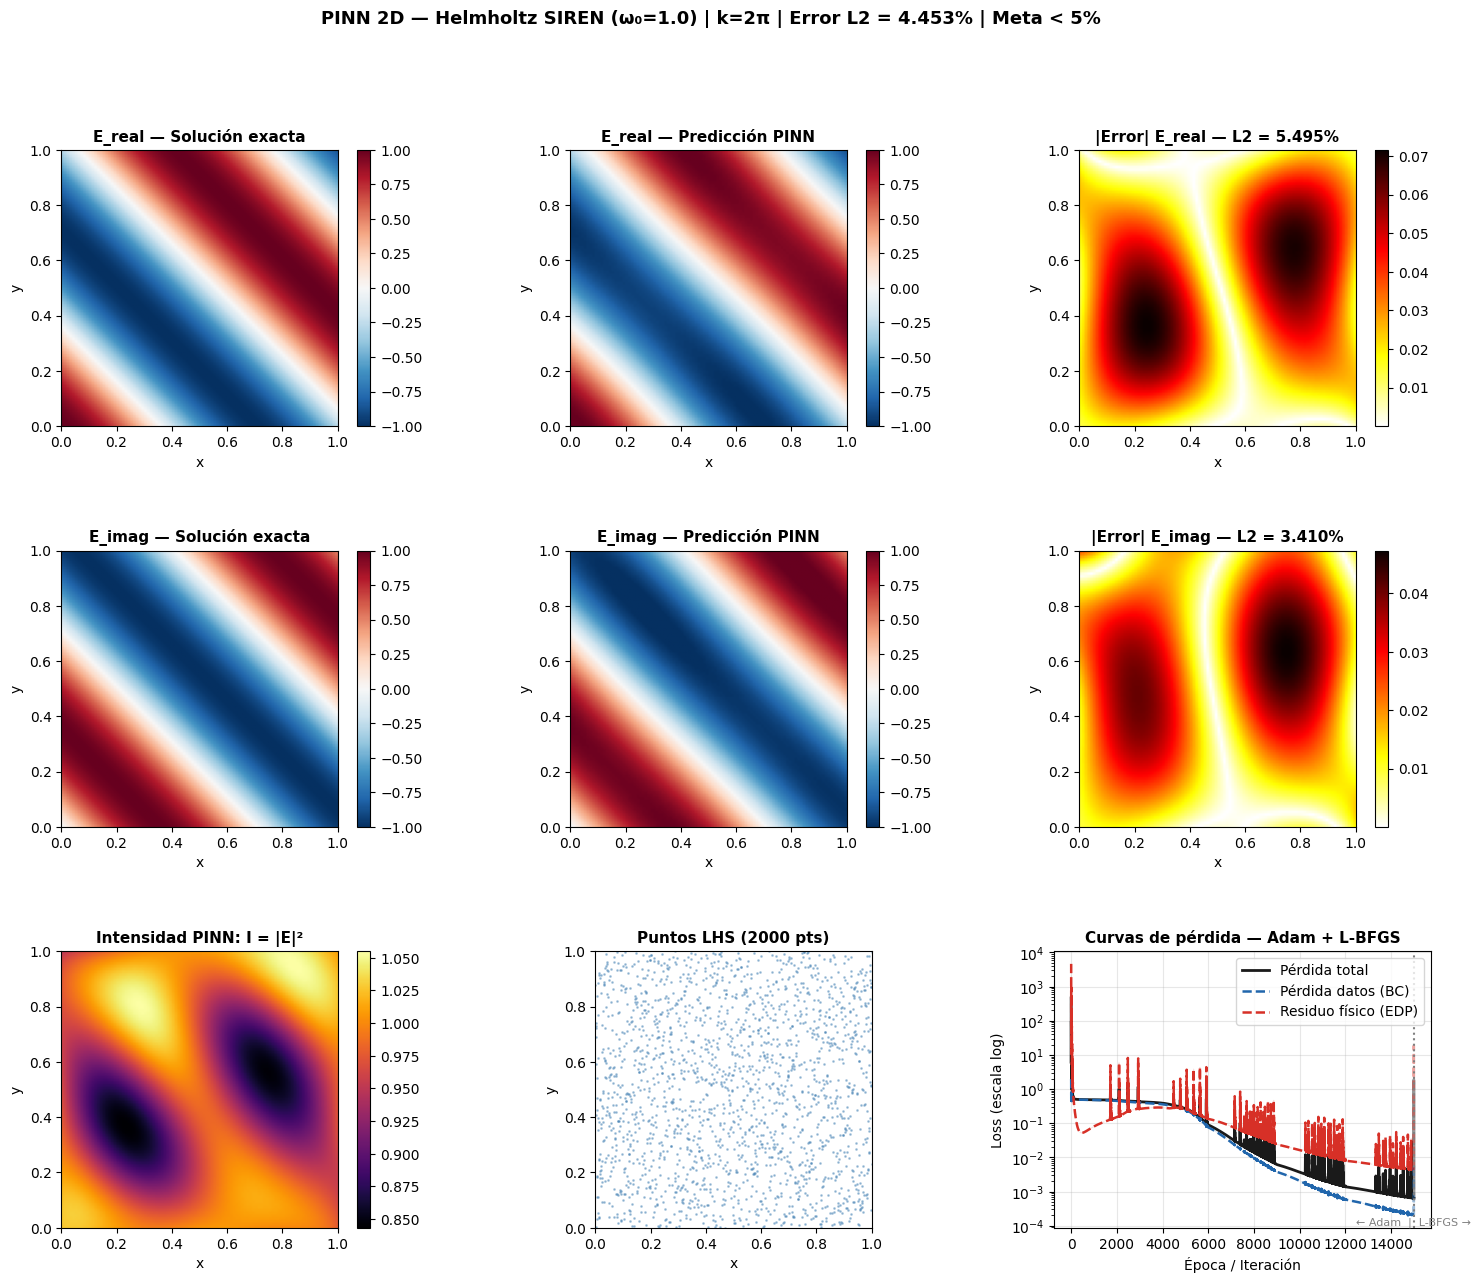

In [8]:
import os
os.makedirs('img', exist_ok=True)

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

cmap_field = 'RdBu_r'
cmap_error = 'hot_r'

COLOR_TOTAL  = '#1a1a1a'
COLOR_DATOS  = '#2166ac'
COLOR_FISICA = '#d73027'

# ── Fila 1: E_real ────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(E_real_exact, origin='lower', extent=[0,1,0,1],
               cmap=cmap_field, vmin=-1, vmax=1)
ax.set_title('E_real — Solución exacta', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(E_real_pred, origin='lower', extent=[0,1,0,1],
               cmap=cmap_field, vmin=-1, vmax=1)
ax.set_title('E_real — Predicción PINN', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(error_real, origin='lower', extent=[0,1,0,1], cmap=cmap_error)
ax.set_title(f'|Error| E_real — L2 = {l2_real*100:.3f}%', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

# ── Fila 2: E_imag ────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
im = ax.imshow(E_imag_exact, origin='lower', extent=[0,1,0,1],
               cmap=cmap_field, vmin=-1, vmax=1)
ax.set_title('E_imag — Solución exacta', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[1, 1])
im = ax.imshow(E_imag_pred, origin='lower', extent=[0,1,0,1],
               cmap=cmap_field, vmin=-1, vmax=1)
ax.set_title('E_imag — Predicción PINN', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[1, 2])
im = ax.imshow(error_imag, origin='lower', extent=[0,1,0,1], cmap=cmap_error)
ax.set_title(f'|Error| E_imag — L2 = {l2_imag*100:.3f}%', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

# ── Fila 3: Intensidad, LHS y pérdida ─────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
im = ax.imshow(I_pred, origin='lower', extent=[0,1,0,1], cmap='inferno')
ax.set_title('Intensidad PINN: I = |E|²', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(gs[2, 1])
xy_lhs_np = xy_colloc.cpu().numpy()
ax.scatter(xy_lhs_np[:, 0], xy_lhs_np[:, 1], s=1, alpha=0.4, c='steelblue')
ax.set_title(f'Puntos LHS ({CONFIG["N_colloc"]} pts)', fontsize=11, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')

# ── Curvas de pérdida — leyendas simplificadas (3 entradas) ───────────────────
ax = fig.add_subplot(gs[2, 2])
ep_adam  = range(1, epoch_final + 1)
ep_lbfgs = range(epoch_final, epoch_final + len(history_lbfgs['total']))

# Raw tenue + sin leyenda
ALPHA_RAW = 0.15
ax.semilogy(ep_adam, history['total'][:epoch_final],
            color=COLOR_TOTAL,  lw=0.8, alpha=ALPHA_RAW)
ax.semilogy(ep_adam, history['data'][:epoch_final],
            color=COLOR_DATOS,  lw=0.8, alpha=ALPHA_RAW, linestyle='--')
ax.semilogy(ep_adam, history['physics'][:epoch_final],
            color=COLOR_FISICA, lw=0.8, alpha=ALPHA_RAW, linestyle='--')

# Líneas principales con leyenda
ax.semilogy(ep_adam, history['total'][:epoch_final],
            color=COLOR_TOTAL,  lw=2,   label='Pérdida total')
ax.semilogy(ep_adam, history['data'][:epoch_final],
            color=COLOR_DATOS,  lw=1.8, linestyle='--', label='Pérdida datos (BC)')
ax.semilogy(ep_adam, history['physics'][:epoch_final],
            color=COLOR_FISICA, lw=1.8, linestyle='--', label='Residuo físico (EDP)')

# L-BFGS — sin leyenda, alpha reducido
ax.semilogy(ep_lbfgs, history_lbfgs['total'],
            color=COLOR_TOTAL,  lw=2,   alpha=0.45)
ax.semilogy(ep_lbfgs, history_lbfgs['data'],
            color=COLOR_DATOS,  lw=1.8, linestyle='--', alpha=0.45)
ax.semilogy(ep_lbfgs, history_lbfgs['physics'],
            color=COLOR_FISICA, lw=1.8, linestyle='--', alpha=0.45)

# Divisoria con anotación directa
ax.axvline(x=epoch_final, color='gray', linestyle=':', lw=1.5)
ax.annotate('← Adam  |  L-BFGS →',
            xy=(epoch_final, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 1e-10),
            fontsize=8, color='gray', ha='center', va='bottom')

ax.set_title('Curvas de pérdida — Adam + L-BFGS', fontsize=11, fontweight='bold')
ax.set_xlabel('Época / Iteración'); ax.set_ylabel('Loss (escala log)')
ax.legend(fontsize=10, loc='upper right'); ax.grid(True, alpha=0.3)

plt.suptitle(
    f'PINN 2D — Helmholtz SIREN (ω₀={CONFIG["omega_0"]}) | k=2π | '
    f'Error L2 = {l2_mean*100:.3f}% | Meta < {CONFIG["l2_threshold"]*100:.0f}%',
    fontsize=13, fontweight='bold'
)
plt.savefig('img/resultados_pinn_2d.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print('=' * 58)
print('RESUMEN DE RESULTADOS — PINN 2D SIREN')
print('=' * 58)
print(f'  Semilla               : {CONFIG["seed"]}')
print(f'  Arquitectura          : SIREN ω₀={CONFIG["omega_0"]} | '
      f'{CONFIG["num_layers"]}×{CONFIG["hidden_dim"]}')
print(f'  k adimensional        : 2π = {k:.4f}')
print(f'  k_x = k_y             : {k_x:.4f}')
print()
print(f'  Error L2 E_real       : {l2_real:.6f}  ({l2_real*100:.3f}%)')
print(f'  Error L2 E_imag       : {l2_imag:.6f}  ({l2_imag*100:.3f}%)')
print(f'  Error L2 promedio     : {l2_mean:.6f}  ({l2_mean*100:.3f}%)')
print(f'  Error máx E_real      : {error_real.max():.6f}')
print(f'  Error máx E_imag      : {error_imag.max():.6f}')
print(f'  Umbral tesis (L2)     : < {CONFIG["l2_threshold"]*100:.0f}%')
print(f'  Estado                : {"CUMPLE" if cumple else "AUN NO CUMPLE — ajustar hiperparámetros"}')
print()
print('Entrenamiento:')
print(f'  Épocas Adam           : {epoch_final} / {CONFIG["n_epochs"]}')
print(f'  Early stopping        : por paciencia ({CONFIG["patience"]} épocas)')
print(f'  LR inicial → final    : {CONFIG["lr"]:.0e} → {history["lr"][-1]:.2e}')
print(f'  Tiempo Adam           : {tiempo_adam:.1f} s')
print(f'  Iteraciones L-BFGS    : {iter_count[0]} / {CONFIG["lbfgs_max_iter"]}')
print(f'  Tiempo L-BFGS         : {tiempo_lbfgs:.1f} s')
print(f'  Tiempo TOTAL          : {tiempo_adam + tiempo_lbfgs:.1f} s')
print()
print('Hiperparámetros:')
print(f'  hidden_dim            = {CONFIG["hidden_dim"]}')
print(f'  num_layers            = {CONFIG["num_layers"]}')
print(f'  omega_0               = {CONFIG["omega_0"]}')
print(f'  N_colloc (LHS)        = {CONFIG["N_colloc"]}')
print(f'  N_boundary (por borde)= {CONFIG["N_boundary"]}  → {4*CONFIG["N_boundary"]} total')
print(f'  lambda_phys           = {CONFIG["lambda_phys"]}')
print(f'  patience              = {CONFIG["patience"]}')
print(f'  scheduler_step        = {CONFIG["scheduler_step"]}')
print(f'  scheduler_gamma       = {CONFIG["scheduler_gamma"]}')
print(f'  lbfgs_max_iter        = {CONFIG["lbfgs_max_iter"]}')
print(f'  lbfgs_history         = {CONFIG["lbfgs_history"]}')
print()
lam = CONFIG['lambda_laser']
L   = CONFIG['L']
print('Láser simulado:')
print(f'  lambda_laser          : {lam * 1e9:.0f} nm')
print(f'  k real equivalente    : {2 * np.pi / lam:.3e} m⁻¹')
print(f'  Dominio simulado      : {L}×{L} λ  →  {L * lam * 1e6:.4f} × {L * lam * 1e6:.4f} μm²')


RESUMEN DE RESULTADOS — PINN 2D SIREN
  Semilla               : 42
  Arquitectura          : SIREN ω₀=1.0 | 5×64
  k adimensional        : 2π = 6.2832
  k_x = k_y             : 4.4429

  Error L2 E_real       : 0.054954  (5.495%)
  Error L2 E_imag       : 0.034103  (3.410%)
  Error L2 promedio     : 0.044529  (4.453%)
  Error máx E_real      : 0.071602
  Error máx E_imag      : 0.047338
  Umbral tesis (L2)     : < 5%
  Estado                : CUMPLE

Entrenamiento:
  Épocas Adam           : 15000 / 15000
  Early stopping        : por paciencia (500 épocas)
  LR inicial → final    : 1e-03 → 3.13e-05
  Tiempo Adam           : 1350.7 s
  Iteraciones L-BFGS    : 7 / 1000
  Tiempo L-BFGS         : 0.3 s
  Tiempo TOTAL          : 1351.1 s

Hiperparámetros:
  hidden_dim            = 64
  num_layers            = 5
  omega_0               = 1.0
  N_colloc (LHS)        = 2000
  N_boundary (por borde)= 200  → 800 total
  lambda_phys           = 0.1
  patience              = 500
  scheduler_step  

---
## ¿Qué sigue?

Con este notebook validaste que la PINN SIREN resuelve Helmholtz **2D** con campo complejo.
El siguiente paso genera el **patrón de speckle óptico** — objetivo central de la tesis:

| Notebook | Contenido | Estado |
|---|---|---|
| `01_teoria_pinns_completo.ipynb` | Helmholtz 1D — validación SIREN ω₀=1.0 | ✅ Error L2 = 0.002% |
| **`02_helmholtz_2D.ipynb`** | **Helmholtz 2D — campo complejo, LHS** | ✅ Este notebook |
| `03_speckle.ipynb` | I(x,y) = |E|² — speckle + estadística | 🔜 Pendiente |
| `04_benchmark.ipynb` | PINN vs FEniCSx — Speed-up Factor | 🔜 Pendiente |
| `05_inhomogeneo_1D.ipynb` | Inhomogéneo 1D — n(x) gradiente lineal | 🔜 Pendiente |
| `06_inhomogeneo_2D.ipynb` | Inhomogéneo 2D — perfiles GRIN y bicapa | 🔜 Pendiente |
| `07_speckle_grin.ipynb` | Speckle en material GRIN — publicable | 🔜 Pendiente |

## Lecciones aprendidas en 2D

| Aspecto | Decisión |
|---|---|
| Arquitectura | SIREN ω₀=1.0 — misma que NB01, validada |
| Campo complejo | Una red, dos salidas: (E_real, E_imag) |
| Muestreo interior | LHS — cobertura uniforme garantizada en [0,1]² |
| Condiciones de frontera | 4 bordes completos, N_b puntos por borde |
| Early stopping | Por paciencia — más robusto que umbral fijo con SIREN |
| lambda_phys | 1.0 — consistente con NB01 |

> **Para NB03:** tomará la predicción E(x,y) de este notebook
> y calculará I = |E|² para generar y analizar el patrón de speckle estadísticamente.